# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.

In [45]:


# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [6]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:


# inspección de plans con .info()
plans.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:

# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:

# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
# cantidad de nulos para users
print("users - nulos por columna:")
print(users.isna().sum())
print("\nusers - proporción de nulos por columna:")
print(users.isna().mean())

users - nulos por columna:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

users - proporción de nulos por columna:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:
# cantidad de nulos para usage
print("\nusage - nulos por columna:")
print(usage.isna().sum())
print("\nusage - proporción de nulos por columna:")
print(usage.isna().mean())


usage - nulos por columna:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

usage - proporción de nulos por columna:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [15]:
✍️ Comentario: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 Nota: Justifica tus decisiones brevemente (1 línea por caso).

Hint:
-Si una columna tiene más del 80–90% de nulos, normalmente se ignora o elimina.
-Si tiene entre 5% y 30%, generalmente se investiga para imputar o dejar como nulos.
-Si es menor al 5%, suele ser un caso simple de imputación o dejar como nulos.

-Valores nulos

-¿Qué columnas tienen valores faltantes y en qué proporción?
-Indica qué harías: ¿imputar, eliminar, ignorar?

- users.city tiene 469 nulos (11.73%).
Acción: investigar e imputar o dejar como nulos, porque está dentro del rango medio (5%–30%) y puede afectar algunos análisis.
    
- users.churn_date tiene 3534 nulos (88.35%).
Acción: ignorar o dejar como está, porque supera el 80% y probablemente representa usuarios activos; no conviene imputar.
    
- usage.date tiene 50 nulos (0.125%).
Acción: imputar o eliminar esos pocos registros, porque es una proporción menor al 5%.
    
- usage.duration tiene 22076 nulos (55.19%).
Acción: investigar antes de imputar, porque es una proporción alta y parece depender del tipo de uso.
    
- usage.length tiene 17896 nulos (44.74%).
Acción: investigar antes de imputar, porque también tiene muchos nulos y probablemente aplica solo a ciertos tipos de eventos.

SyntaxError: invalid character '✍' (U+270D) (3043758818.py, line 1)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
# explorar columnas numéricas de users
print("Resumen numérico de users:")
print(users[['user_id', 'age']].describe())

Resumen numérico de users:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna age: aparece un valor mínimo de -999, que no es una edad válida, Hay reemplazarlo por NaN y luego decidir si se imputa o se elimina.

In [17]:
# explorar columnas numéricas de usage
print("\nResumen numérico de usage:")
print(usage[['id', 'user_id', 'duration', 'length']].describe())


Resumen numérico de usage:
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


In [18]:
- La columna `duration`aqui el mínimo es 0 y el máximo es 120, hay que revisar si los ceros corresponden a datos válidos; si son registros reales, se dejan.

- La columna `lenght`aqui el máximo es 1490, lo cual parece un valor muy alto, hay que revisar si es un caso extremo o un error de captura antes de decidir si se corrige o elimina.

SyntaxError: invalid syntax (3813153662.py, line 1)

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts(dropna=False))


Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` aqui aparece el valor ?, que funciona como sentinel porque representa un dato desconocido o mal capturado, hay que reemplazarlo por NaN para tratarlo como valor faltante
- La columna `plan` solo aparecen Basico y Premium, que parecen valores válidos, no requiere corrección.


In [20]:
# explorar columna categórica de usage
print("\nValores únicos en type:")
print(usage['type'].value_counts(dropna=False))


Valores únicos en type:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` solo aparecen text y call, que son categorías esperadas, no requiere limpieza.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
Los principales sentinels detectados son age = -999 y city = ?

- ¿Qué acción tomarías?
La acción recomendada es convertirlos a valores faltantes (NaN) para tratarlos de forma adecuada en la limpieza posterior.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [23]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())


Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En reg_date, se observan años válidos entre 2022 y 2024, pero también aparece 2026, que es un año fuera de rango, Hay que corregirlo o convertirlo en NaT porque parece un error de captura.

In [24]:
# Revisar los años presentes en `date` de usage
print("\nAños en date:")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())



Años en date:
2024.0    39950
NaN          50
Name: date, dtype: int64


En date, todas las fechas válidas están en 2024, y solo hay algunos valores nulos, no hay años imposibles; los nulos pueden revisarse o eliminarse según su importancia.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)


  Sí, sí aparece un año imposible: reg_date tiene registros en 2026, y como el análisis solo considera datos hasta 2024, ese año no debería existir.
  date no muestra años imposibles; solo aparecen fechas de 2024 y algunos NaN.
  
- ¿Qué harías con ellas?

para reg_date hay que convertir esos valores en NaT o eliminarlos, porque parecen un error de captura.
en date hay que revisar o eliminar los nulos si son necesarios para el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [27]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [30]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration por tipo:")
print(usage[usage['duration'].isna()]['type'].value_counts(dropna=False))

print("\nProporción de nulos en duration por tipo:")
print(pd.crosstab(usage['type'], usage['duration'].isna(), normalize='index'))

Nulos en duration por tipo:
text    22076
Name: type, dtype: int64

Proporción de nulos en duration por tipo:
duration     False     True 
type                        
call      1.000000  0.000000
text      0.000724  0.999276


In [31]:
# Verificación MAR en usage (Missing At Random) para length
print("\nNulos en length por tipo:")
print(usage[usage['length'].isna()]['type'].value_counts(dropna=False))

print("\nProporción de nulos en length por tipo:")
print(pd.crosstab(usage['type'], usage['length'].isna(), normalize='index'))


Nulos en length por tipo:
call    17896
Name: type, dtype: int64

Proporción de nulos en length por tipo:
length    False    True 
type                    
call    0.00067  0.99933
text    1.00000  0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

En duration, los nulos dependen del valor de type, por lo que parecen ser Missing At Random (MAR), hay dejarlos como nulos, ya que corresponden a registros donde esa variable no aplica.
En length, ocurre el mismo patrón: los nulos dependen de type, así que también son MAR, es mejor conservarlos como nulos, porque representan casos donde la variable no aplica.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [32]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id", as_index=False)[["is_text", "is_call", "duration"]].sum().reset_index(drop=True)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

# revisar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [35]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())


               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [36]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

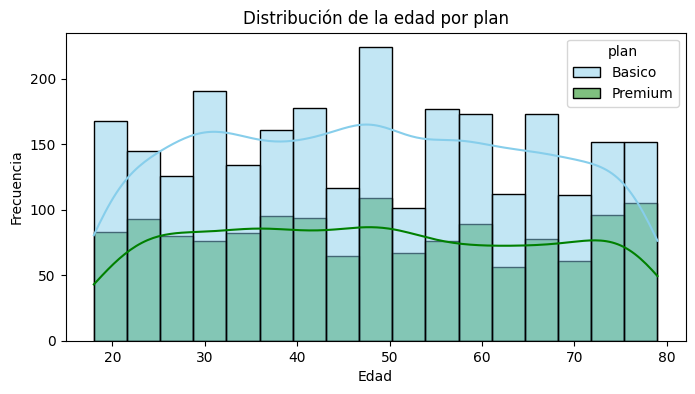

In [37]:
# 1) Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True, alpha=0.5)
plt.title('Distribución de la edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
-Distribución: bastante dispersa y casi plana; no se ve un sesgo fuerte.

-Insight: ambos planes tienen usuarios en un rango de edades muy parecido. El plan Básico aparece con más frecuencia porque hay más usuarios, pero no se observa una diferencia clara por edad entre planes.

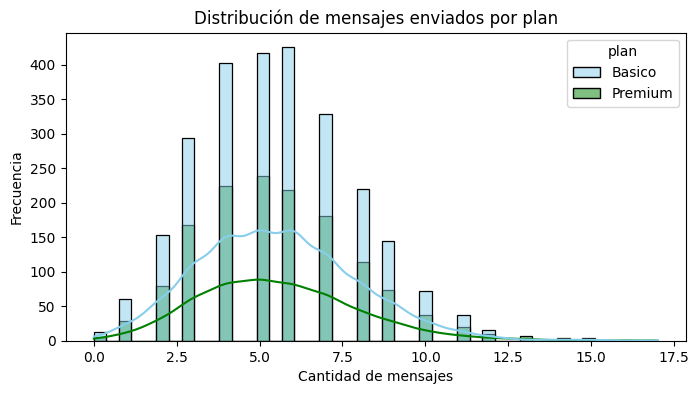

In [38]:
# 2) Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True, alpha=0.5)
plt.title('Distribución de mensajes enviados por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: sesgada a la derecha.

-Insight: la mayoría de los usuarios envía entre 3 y 7 mensajes. El plan Básico concentra más usuarios en casi todos los valores, pero la forma general de la distribución es muy similar en ambos planes.

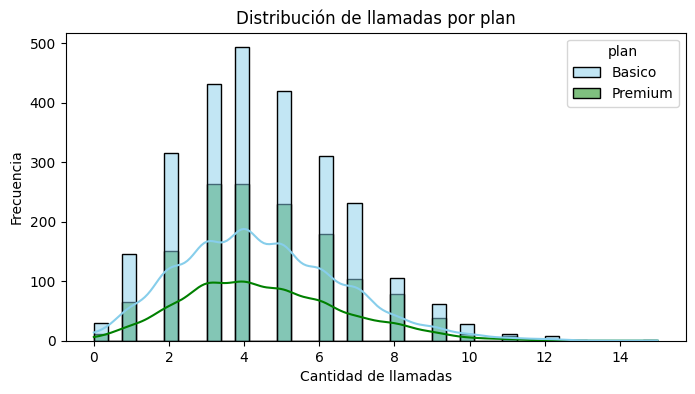

In [39]:
# 3) Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True, alpha=0.5)
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: sesgada a la derecha.
- 
- Insight: la mayor parte de los usuarios realiza entre 2 y 6 llamadas. Nuevamente, el plan Básico muestra más frecuencia total, aunque no se aprecia una diferencia fuerte en el patrón de llamadas entre planes.

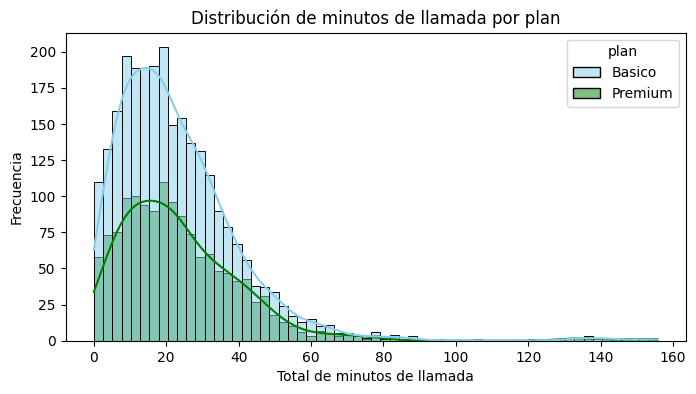

In [40]:
# 4) Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True, alpha=0.5)
plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: claramente sesgada a la derecha.

-Insight: la mayoría de los usuarios acumula pocos minutos de llamada, mientras que unos pocos llegan a valores muy altos. El plan Básico tiene más observaciones en general, pero ambos planes comparten una distribución muy parecida, con una cola larga hacia la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

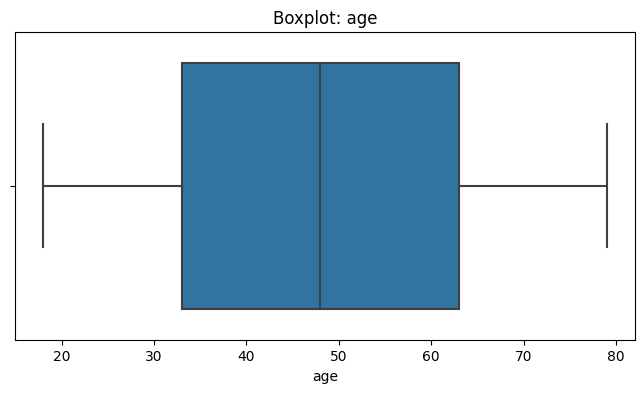

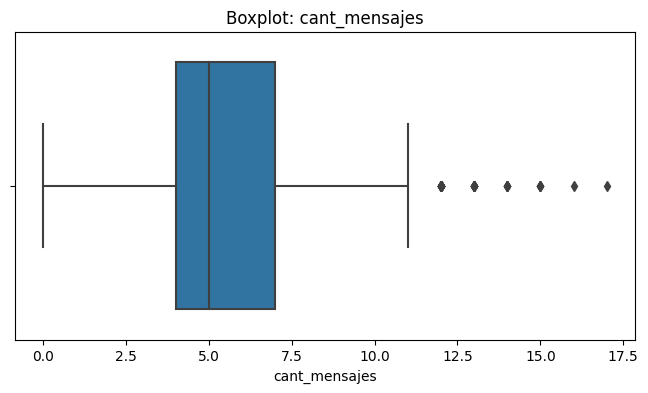

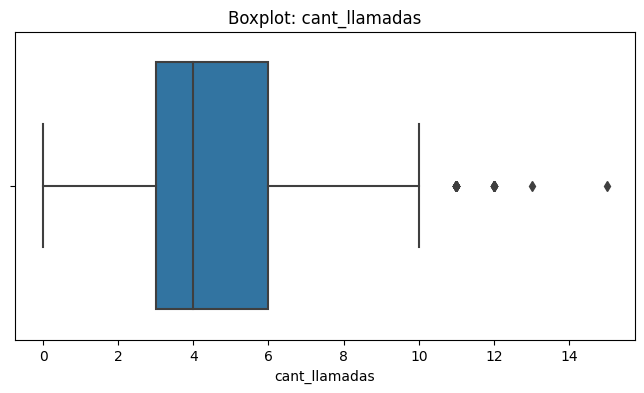

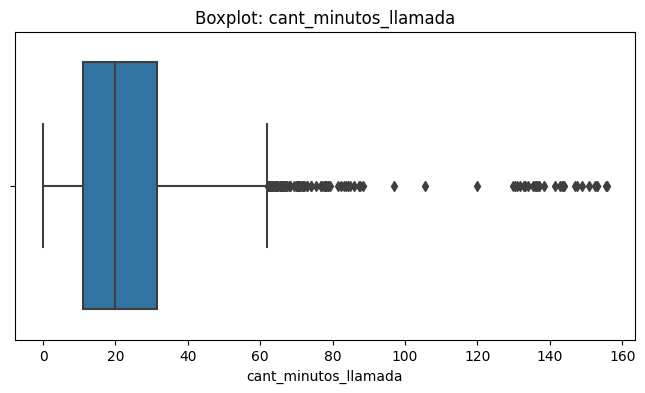

In [41]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:

-age: no presenta outliers importantes.

-cant_mensajes: presenta outliers superiores, ya que el máximo real (17) supera el límite superior (11.5).

cant_llamadas: también presenta outliers superiores, porque el máximo real (15) supera el límite superior (10.5).

cant_minutos_llamada: presenta muchos outliers superiores, con un máximo real (155.69) muy por encima del límite superior (61.86).


In [42]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    print(f"{col}:")
    print(f"  Límite inferior: {limite_inferior}")
    print(f"  Límite superior: {limite_superior}")
    print(f"  Máximo real: {user_profile[col].max()}\n")

cant_mensajes:
  Límite inferior: -0.5
  Límite superior: 11.5
  Máximo real: 17.0

cant_llamadas:
  Límite inferior: -1.5
  Límite superior: 10.5
  Máximo real: 15.0

cant_minutos_llamada:
  Límite inferior: -19.322500000000005
  Límite superior: 61.8575
  Máximo real: 155.69



In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  mantenerlos, parecen ser usuarios intensivos reales, no errores de captura.
  
- cant_llamadas: mantener o no outliers, porqué?
mantenerlos, También representan comportamiento real de algunos usuarios.


- cant_minutos_llamada: mantener o no outliers, porqué?
mantenerlos, ya que los valores altos son coherentes con usuarios de alto uso; eliminarlos podría borrar información valiosa.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [46]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

# Verificar resultado
user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(10)

,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso
5,10005,7.0,5.0,Uso medio
6,10006,5.0,3.0,Uso medio
7,10007,5.0,3.0,Uso medio
8,10008,5.0,5.0,Uso medio
9,10009,3.0,5.0,Uso medio


In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [48]:
# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

opciones_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

# Verificar resultado
user_profile[['user_id', 'age', 'grupo_edad']].head(10)


,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor
5,10005,61.0,Adulto Mayor
6,10006,39.0,Adulto
7,10007,70.0,Adulto Mayor
8,10008,76.0,Adulto Mayor
9,10009,47.0,Adulto


In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

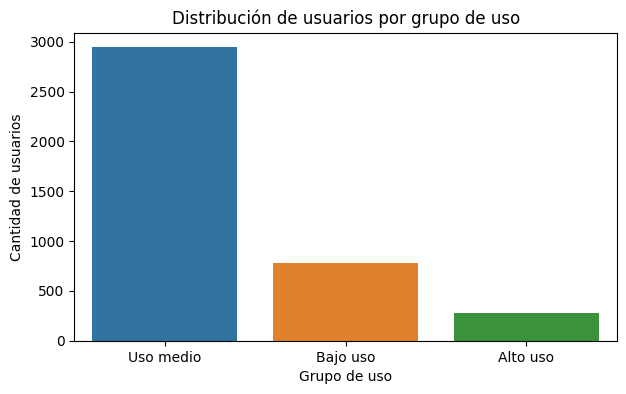

In [50]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=0)
plt.show()

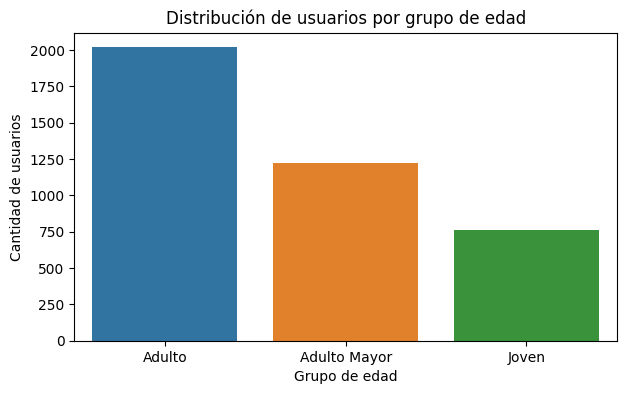

In [51]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_edad', order=user_profile['grupo_edad'].value_counts().index)
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=0)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

-users.city presentó 469 nulos (11.73%) y además 96 valores ? que funcionaban como sentinel.
Tras corregirlos, quedaron 565 registros afectados en total (14.13%).
se decidio estandarizar ? como nulo y revisar si conviene imputar o dejar como faltante.

-users.age contenía el sentinel -999, que no es una edad válida.
Acción: se reemplazó por la mediana, ya que representa un error de captura.
users.reg_date tenía 40 registros en 2026.
Como el análisis solo llega hasta 2024, esas fechas son imposibles.
se decidio marcarlas como NaT o eliminarlas.

-users.churn_date tenía 3534 nulos (88.35%).
Acción: no imputarlos; probablemente significan usuarios activos.
usage.date tenía 50 nulos (0.125%).
como son pocos; se pueden eliminar o revisar caso por caso.

-usage.duration y usage.length tenían muchos nulos, pero el patrón depende de type (call vs text).
se decidio dejarlos como nulos porque parecen ser MAR.

🔍 **Segmentos por Edad**

-Se identificaron tres grupos:
Joven: menores de 30
Adulto: de 30 a 59
Adulto Mayor: 60 o más

-La distribución de edades sugiere que la mayor parte de los clientes se concentra en edades medias y altas, con presencia de usuarios jóvenes pero menor peso relativo.

-No se observa una separación muy marcada por plan; ambos planes aparecen repartidos en rangos de edad similares.


📊 **Segmentos por Nivel de Uso**

-Se identificaron tres grupos:
Bajo uso
Uso medio
Alto uso

-La mayoría de los usuarios parece concentrarse en perfiles de uso bajo o medio, mientras que los usuarios de alto uso son menos frecuentes pero claramente más intensivos.

-Las variables de uso muestran distribuciones sesgadas a la derecha, lo que indica que unos pocos usuarios concentran mucho más tráfico que el resto.


➡️ Esto sugiere que ...

-Existe un grupo pequeño de clientes intensivos que genera una parte importante del uso total.

-También hay una base amplia de usuarios de consumo moderado o bajo, que podría responder bien a planes más simples o económicos.

-Los clientes de alto uso son especialmente valiosos porque probablemente concentran mayor ingreso potencial y oportunidades de upselling.

💡 **Recomendaciones**

-Mantener y reforzar el plan Premium para usuarios de alto uso, ya que son los que más valor aportan.

-Crear o ajustar un plan intermedio para usuarios de uso medio, con límites más flexibles y mejor relación costo-beneficio.

-Ofrecer un plan económico para usuarios jóvenes o de bajo uso, con pocos mensajes y llamadas incluidas.

-Diseñar estrategias de upselling para usuarios de Básico que ya muestran consumo alto.

-No eliminar los outliers de uso, porque probablemente representan clientes reales de alto valor y no errores.

-Monitorear las fechas y campos inválidos para mejorar la calidad del dato en futuras cargas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`